# 13 — `detect_ripples`: end-to-end pipeline

Composes filt → hilbert → smoothing → threshold to find sharp-wave
ripples in an LFP-style signal. Returns a `pandas.DataFrame` with
`start_s`, `end_s`, `peak_s`, `duration_s`, `rel_peak_pos`, and
`peak_amp_sd` for each detected event.

Needs the optional `ripple_detection` package.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scitex_dsp as dsp
%matplotlib inline

np.random.seed(0)
xx, tt, fs = dsp.demo_sig(sig_type="ripple", batch_size=1, n_chs=1,
                          t_sec=5, fs=1000)
print("input:", xx.shape, "fs:", fs)

input: (1, 1, 5000) fs: 1000


## Detect

In [2]:
df, xx_pre, fs_pre = dsp.detect_ripples(
    xx, fs=fs, low_hz=150, high_hz=250,
    return_preprocessed_signal=True,
)
print(f"detected {len(df)} ripples")
df

detected 5 ripples


,start_s,end_s,duration_s,peak_s,rel_peak_pos,peak_amp_sd
0,0.346,0.446,0.100,0.397,0.510,4.158
0,0.595,0.704,0.109,0.635,0.367,4.245
0,3.773,3.880,0.107,3.834,0.570,4.331
0,4.510,4.616,0.106,4.571,0.575,4.323
0,4.789,4.891,0.102,4.835,0.451,4.232


## Visualize

Top: raw LFP. Bottom: ripple-band envelope (z). Detected events shaded with `axvspan`, peaks marked with `axvline`.

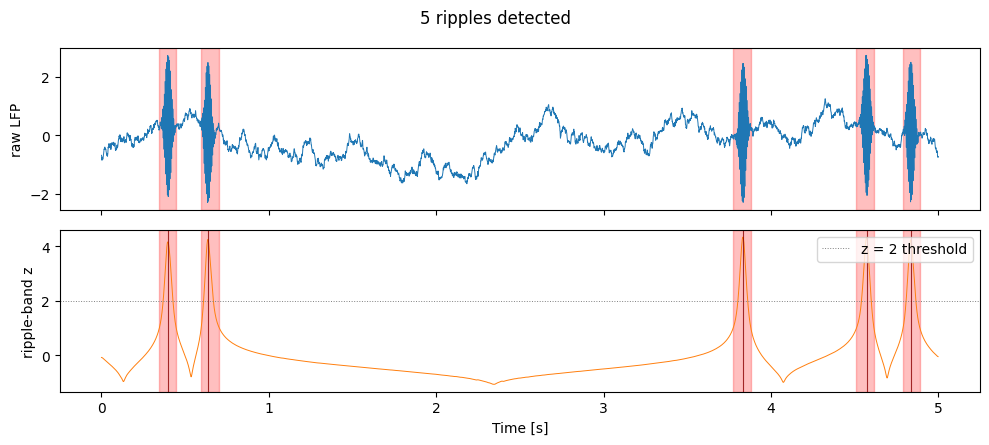

In [3]:
xx_pre_np = np.asarray(xx_pre)
trace = xx_pre_np.reshape(-1, xx_pre_np.shape[-1])[0]
t_pre = np.arange(trace.size) / fs_pre

fig, ax = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)
ax[0].plot(tt, xx[0, 0], lw=0.7);  ax[0].set_ylabel("raw LFP")
ax[1].plot(t_pre, trace, lw=0.7, color="C1")
ax[1].axhline(2.0, color="grey", ls=":", lw=0.7, label="z = 2 threshold")
ax[1].set_ylabel("ripple-band z")
ax[1].set_xlabel("Time [s]")
ax[1].legend(loc="upper right")

for _, row in df.iterrows():
    for a in ax:
        a.axvspan(row["start_s"], row["end_s"], color="red", alpha=0.25)
    ax[1].axvline(row["peak_s"], color="darkred", lw=0.8, alpha=0.8)

fig.suptitle(f"{len(df)} ripples detected")
fig.tight_layout()
plt.show()

## Per-ripple summary

In [4]:
df[["start_s", "end_s", "peak_s", "duration_s", "peak_amp_sd"]].describe()

,start_s,end_s,peak_s,duration_s,peak_amp_sd
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.802600,2.907400,2.854400,0.104800,4.257800
std,2.162814,2.162949,2.167583,0.003701,0.071412
min,0.346000,0.446000,0.397000,0.100000,4.158000
25%,0.595000,0.704000,0.635000,0.102000,4.232000
50%,3.773000,3.880000,3.834000,0.106000,4.245000
75%,4.510000,4.616000,4.571000,0.107000,4.323000
max,4.789000,4.891000,4.835000,0.109000,4.331000


That's the full `scitex_dsp` tour: signal → shape → normalize → filter → hilbert → spectral → wavelet → resample → noise → reference → MI → PAC → detection.